# Project 1: E-Commerce Intelligence — Step 3: Demand Forecasting

> **Branch:** `feature/demand-forecasting`  
> **Dataset:** Olist Brazilian E-Commerce (Sep 2016 – Aug 2018)  
> **Task:** Multi-step time-series regression — forecast weekly order volume per product category

## Pipeline Overview
| Stage | Description |
|---|---|
| 1 | Data ingestion & weekly time-series construction |
| 2 | Exploratory Time-Series Analysis (ACF/PACF, decomposition, ADF) |
| 3 | Feature Engineering (lags, rolling stats, calendar, holidays) |
| 4 | Temporal Train / Val / Test split |
| 5 | Baseline models (Naive, Seasonal Naive, Rolling Mean) |
| 6 | SARIMA (statsmodels) |
| 7 | Regularized Linear Models (Ridge / Lasso / ElasticNet) |
| 8 | Gradient Boosting — LightGBM + XGBoost with **GPU** + **Optuna** HPO |
| 9 | Stacking Ensemble (LGB + XGB → Ridge meta-learner) |
| 10 | Model Comparison & Visualizations |
| 11 | SHAP Explainability |
| 12 | Bonus: Price Regression |
| 13 | Model Persistence |

## Section 0 — Setup & Imports

In [9]:
# ── Core ──────────────────────────────────────────────────────────────────────
import warnings, sqlite3, os, joblib
import numpy as np
import pandas as pd
warnings.filterwarnings('ignore')
np.random.seed(42)

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
PLOT_DIR = '../../reports/figures/ecommerce_intelligence'
os.makedirs(PLOT_DIR, exist_ok=True)
os.makedirs('../../models/ecommerce_intelligence', exist_ok=True)
os.makedirs('../../data/processed/ecommerce_intelligence', exist_ok=True)

# ── Stats / Forecasting ───────────────────────────────────────────────────────
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ── Sklearn ───────────────────────────────────────────────────────────────────
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Gradient Boosting (GPU) ───────────────────────────────────────────────────
import lightgbm as lgb
import xgboost as xgb

# ── Hyperparameter Optimisation ───────────────────────────────────────────────
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Explainability ────────────────────────────────────────────────────────────
import shap

# ── Holidays ──────────────────────────────────────────────────────────────────
import holidays

print('All imports successful ✓')
print(f'LightGBM {lgb.__version__} | XGBoost {xgb.__version__}')

All imports successful ✓
LightGBM 4.6.0 | XGBoost 3.2.0


## Section 1 — Data Ingestion & Time-Series Construction

In [10]:
DB_PATH = '../datasets/ecommerce/ecommerce.db'
conn = sqlite3.connect(DB_PATH)

query = """
SELECT
    o.order_purchase_timestamp,
    oi.order_id,
    oi.product_id,
    oi.price,
    oi.freight_value,
    COALESCE(t.product_category_name_english, p.product_category_name, 'unknown') AS category
FROM olist_orders o
JOIN olist_order_items oi ON o.order_id = oi.order_id
JOIN olist_products p     ON oi.product_id = p.product_id
LEFT JOIN product_category_name_translation t
    ON p.product_category_name = t.product_category_name
WHERE o.order_status = 'delivered'
  AND o.order_purchase_timestamp IS NOT NULL
"""

raw = pd.read_sql(query, conn, parse_dates=['order_purchase_timestamp'])
conn.close()

print(f'Raw rows: {len(raw):,}')
print(f'Date range: {raw.order_purchase_timestamp.min()} → {raw.order_purchase_timestamp.max()}')
print(f'Unique categories: {raw.category.nunique()}')
raw.head(3)

Raw rows: 110,197
Date range: 2016-09-15 12:16:38 → 2018-08-29 15:00:37
Unique categories: 74


,order_purchase_timestamp,order_id,product_id,price,freight_value,category
0,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,87285b34884572647811a353c7ac498a,29.99,8.72,housewares
1,2018-07-24 20:41:37,53cdb2fc8bc7dce0b6741e2150273451,595fac2a385ac33a80bd5114aec74eb8,118.70,22.76,perfumery
2,2018-08-08 08:38:49,47770eb9100c2d0c44946d9cf07ec65d,aa4383b373c6aca5d8797843e5594415,159.90,19.22,auto


In [11]:
# ── Select Top-10 categories by total order volume ───────────────────────────
top10_cats = (
    raw.groupby('category')['order_id']
    .count()
    .nlargest(10)
    .index.tolist()
)
print('Top-10 categories:', top10_cats)

df = raw[raw['category'].isin(top10_cats)].copy()

# ── Weekly resampling: orders, revenue, avg_price ────────────────────────────
df['week'] = df['order_purchase_timestamp'].dt.to_period('W').dt.start_time

weekly = (
    df.groupby(['week', 'category'])
    .agg(
        orders=('order_id', 'count'),
        revenue=('price', 'sum'),
        avg_price=('price', 'mean'),
        avg_freight=('freight_value', 'mean')
    )
    .reset_index()
)

# ── Ensure complete grid (all weeks × all categories) ────────────────────────
all_weeks = pd.date_range(
    weekly['week'].min(), weekly['week'].max(), freq='W-MON'
)
full_idx = pd.MultiIndex.from_product(
    [all_weeks, top10_cats], names=['week', 'category']
)
weekly = (
    weekly.set_index(['week', 'category'])
    .reindex(full_idx, fill_value=0)
    .reset_index()
)
# fill avg_price with forward fill per category (price doesn't go to 0)
weekly['avg_price'] = (
    weekly.groupby('category')['avg_price']
    .transform(lambda s: s.replace(0, np.nan).ffill().bfill())
)

print(f'Weekly grid shape: {weekly.shape}')
print(f'Weeks per category: {weekly.groupby("category")["week"].count().unique()}')
weekly.head()

Top-10 categories: ['bed_bath_table', 'health_beauty', 'sports_leisure', 'furniture_decor', 'computers_accessories', 'housewares', 'watches_gifts', 'telephony', 'garden_tools', 'auto']
Weekly grid shape: (1030, 6)
Weeks per category: [103]


,week,category,orders,revenue,avg_price,avg_freight
0,2016-09-12,bed_bath_table,0,0.00,59.873750,0.00
1,2016-09-12,health_beauty,3,134.97,44.990000,2.83
2,2016-09-12,sports_leisure,0,0.00,133.733571,0.00
3,2016-09-12,furniture_decor,0,0.00,80.040357,0.00
4,2016-09-12,computers_accessories,0,0.00,59.092727,0.00


## Section 2 — Exploratory Time-Series Analysis

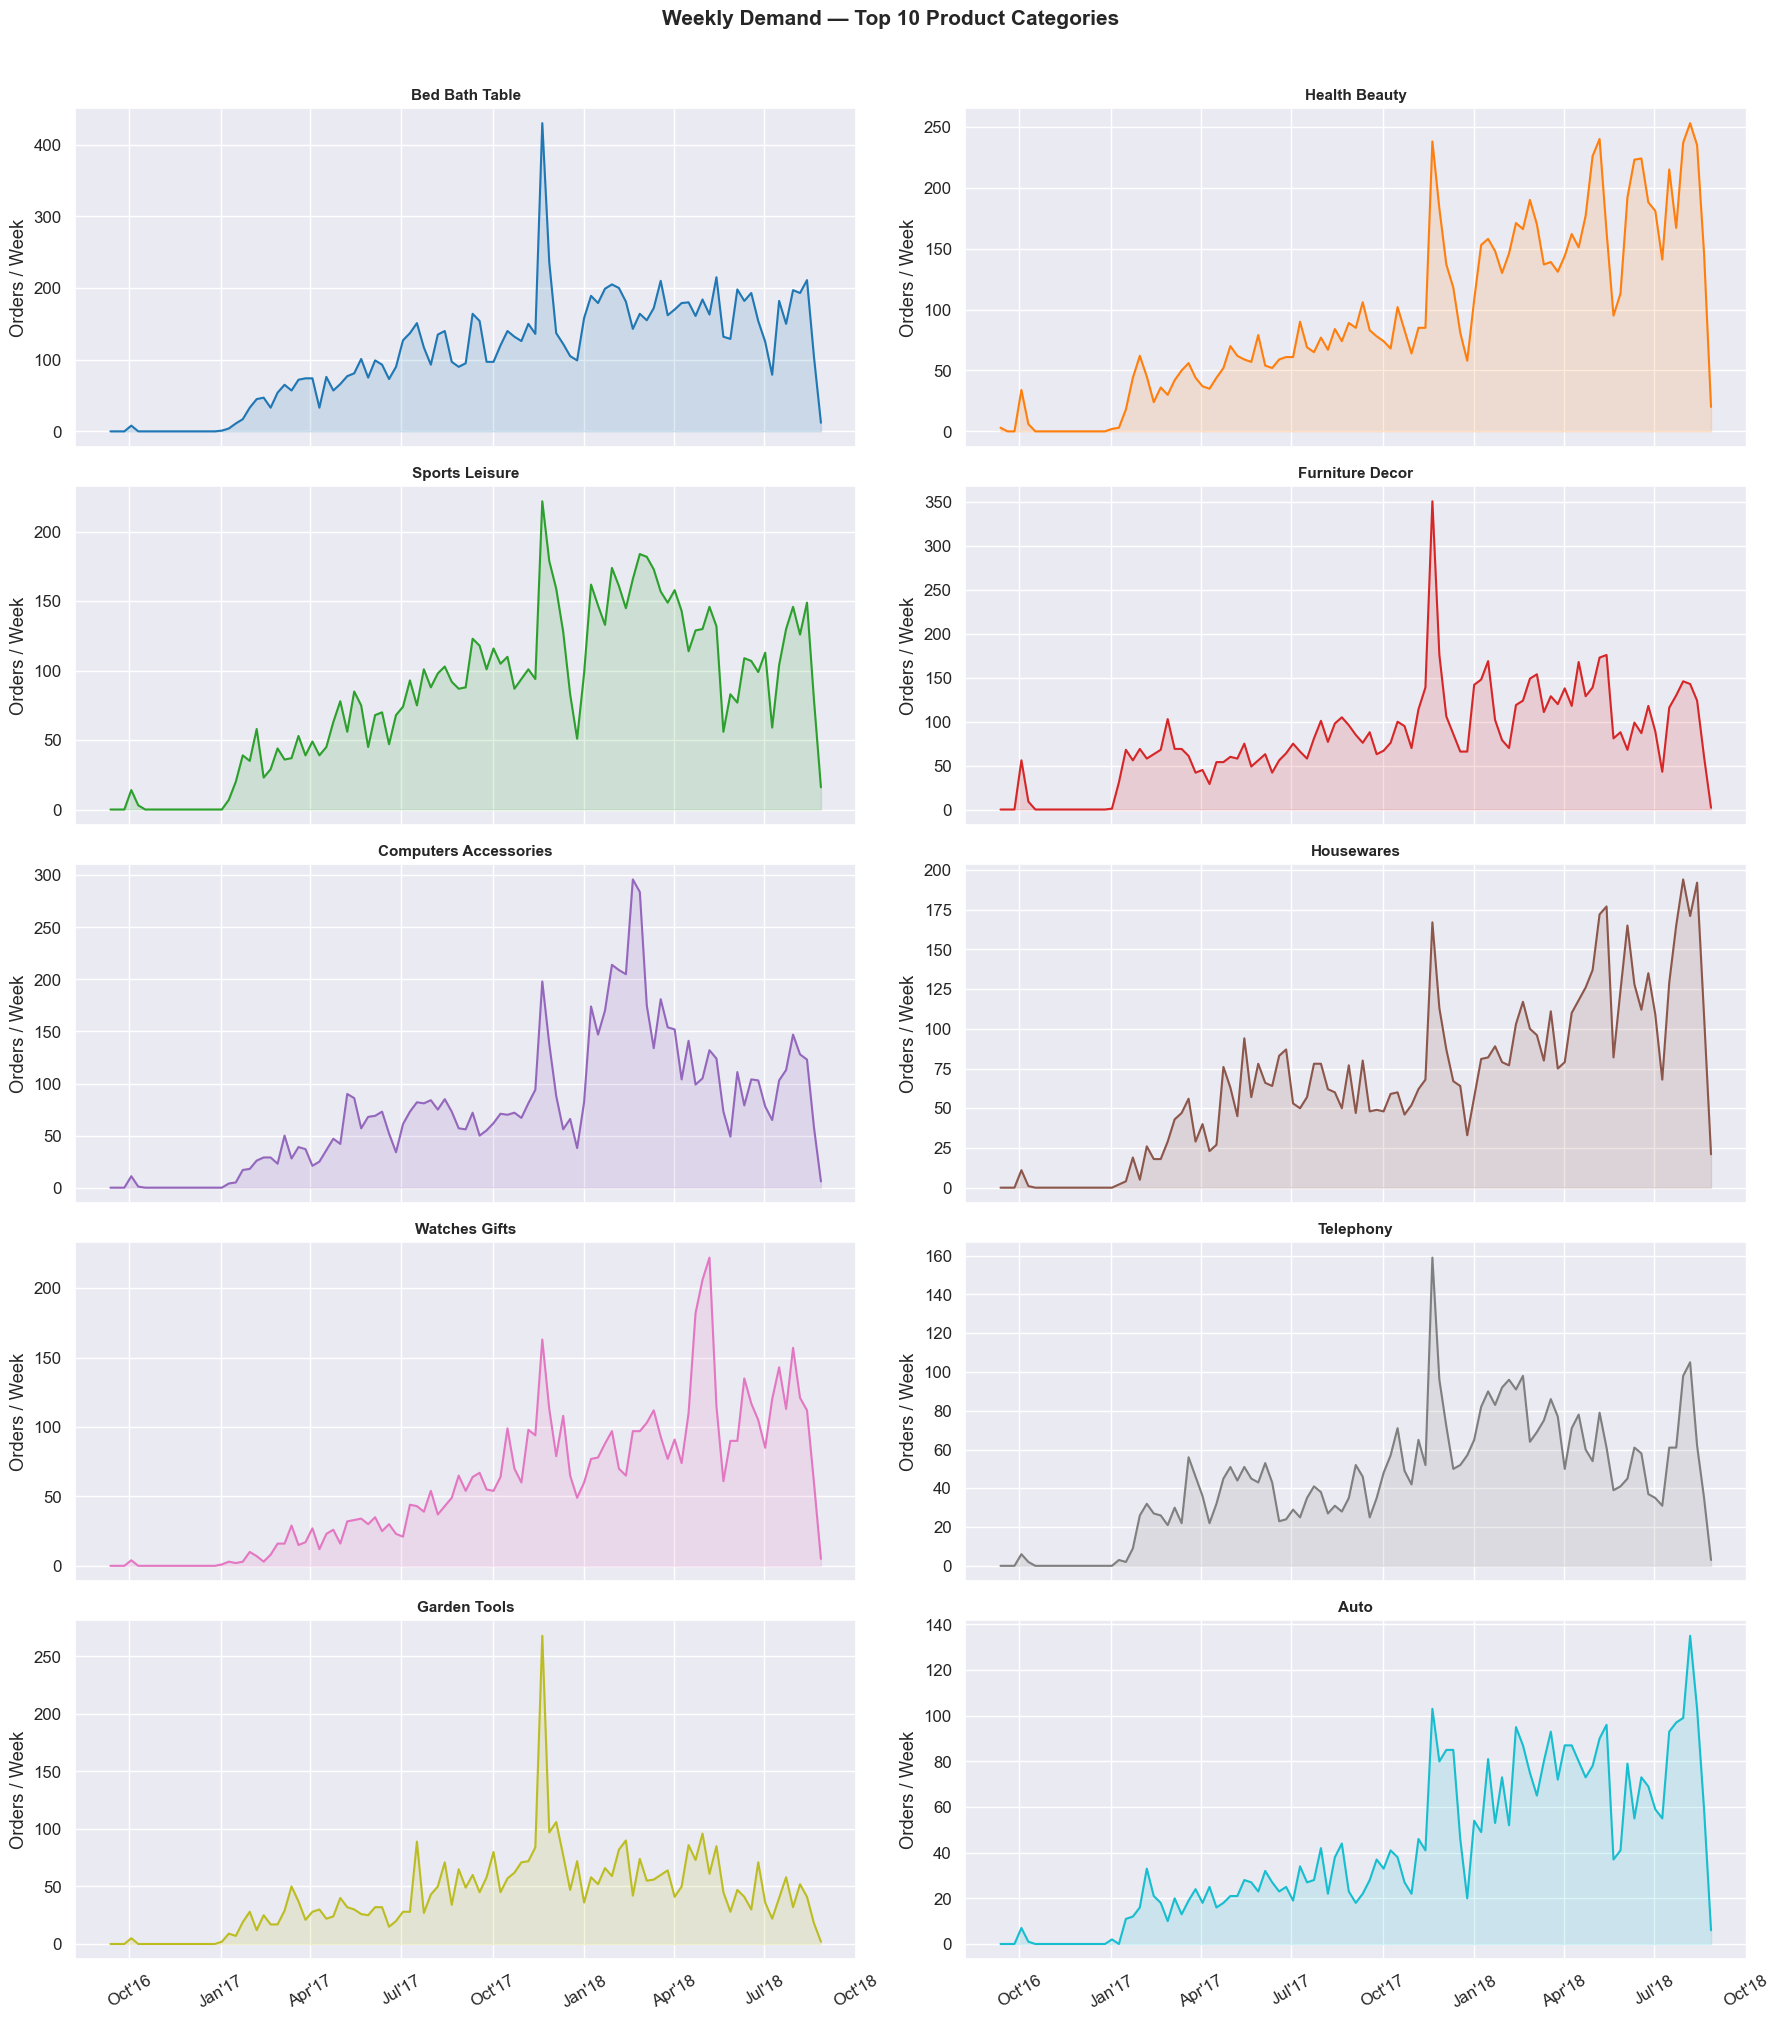

Plot saved ✓


In [12]:
# ── Raw demand curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(5, 2, figsize=(18, 20), sharex=True)
axes = axes.flatten()
palette = sns.color_palette('tab10', 10)

for i, cat in enumerate(top10_cats):
    data = weekly[weekly['category'] == cat].set_index('week')['orders']
    axes[i].plot(data.index, data.values, color=palette[i], linewidth=1.5)
    axes[i].fill_between(data.index, data.values, alpha=0.15, color=palette[i])
    axes[i].set_title(cat.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Orders / Week')
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b\'%y'))
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Weekly Demand — Top 10 Product Categories', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_weekly_demand_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

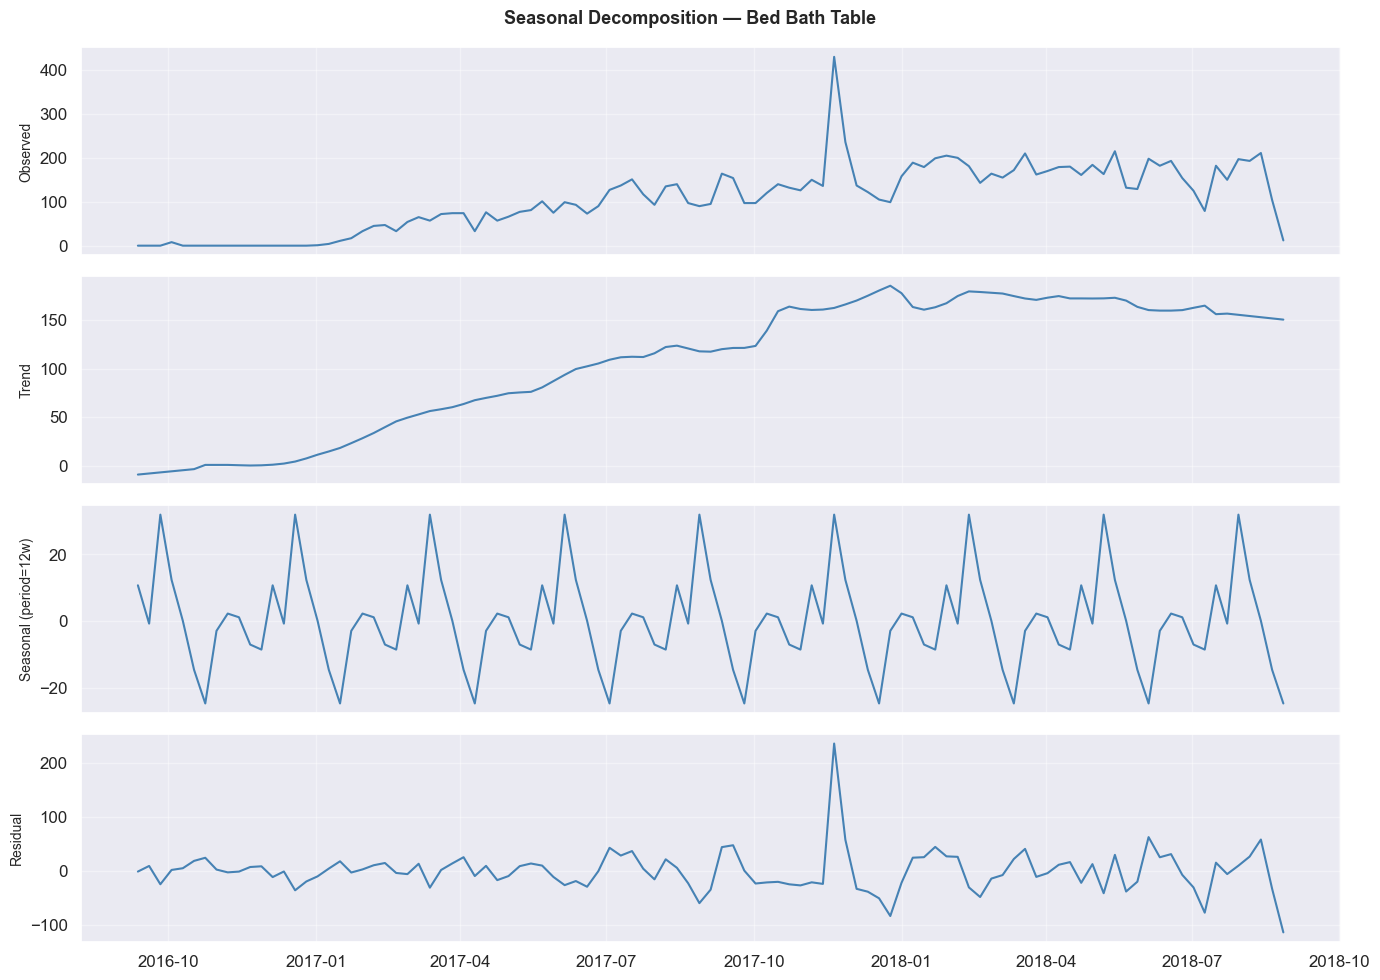

In [13]:
# ── Seasonal decomposition on the highest-volume category ────────────────────
focus_cat = top10_cats[0]  # bed_bath_table
series_focus = (
    weekly[weekly['category'] == focus_cat]
    .set_index('week')['orders']
    .asfreq('W-MON')
)

decomp = seasonal_decompose(series_focus, model='additive', period=12, extrapolate_trend='freq')

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
for ax, comp, label in zip(
    axes,
    [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
    ['Observed', 'Trend', 'Seasonal (period=12w)', 'Residual']
):
    ax.plot(comp, color='steelblue')
    ax.set_ylabel(label, fontsize=10)
    ax.grid(True, alpha=0.4)

fig.suptitle(f'Seasonal Decomposition — {focus_cat.replace("_"," ").title()}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_seasonal_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

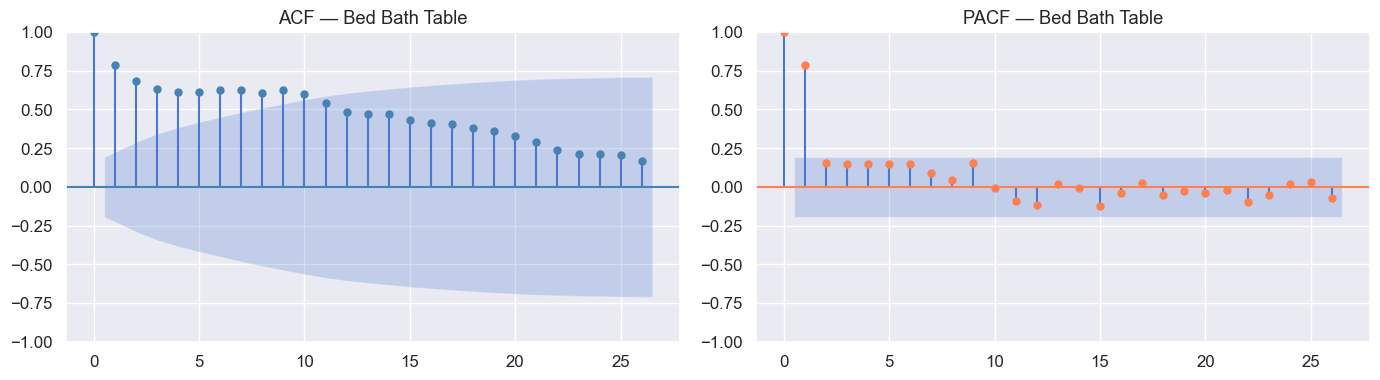

=== Augmented Dickey-Fuller Test ===
             category  ADF_stat  p_value stationary
       bed_bath_table    -1.721   0.4202          ✗
        health_beauty    -0.324   0.9220          ✗
       sports_leisure    -1.688   0.4373          ✗
      furniture_decor    -3.828   0.0026          ✓
computers_accessories    -1.755   0.4030          ✗
           housewares    -1.075   0.7248          ✗
        watches_gifts    -1.155   0.6925          ✗
            telephony    -1.855   0.3536          ✗
         garden_tools    -3.073   0.0286          ✓
                 auto    -2.891   0.0464          ✓


In [14]:
# ── ACF / PACF plots ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(series_focus, lags=26, ax=axes[0], color='steelblue')
axes[0].set_title(f'ACF — {focus_cat.replace("_"," ").title()}')
plot_pacf(series_focus, lags=26, ax=axes[1], method='ywm', color='coral')
axes[1].set_title(f'PACF — {focus_cat.replace("_"," ").title()}')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Augmented Dickey-Fuller stationarity test ─────────────────────────────────
print('=== Augmented Dickey-Fuller Test ===')
results_list = []
for cat in top10_cats:
    s = weekly[weekly['category'] == cat].set_index('week')['orders'].asfreq('W-MON')
    adf_stat, p_val, _, _, _, _ = adfuller(s, autolag='AIC')
    results_list.append({'category': cat, 'ADF_stat': round(adf_stat, 3),
                         'p_value': round(p_val, 4),
                         'stationary': '✓' if p_val < 0.05 else '✗'})

adf_df = pd.DataFrame(results_list)
print(adf_df.to_string(index=False))

## Section 3 — Feature Engineering

In [15]:
# ── Brazilian public holidays ─────────────────────────────────────────────────
br_holidays = holidays.Brazil(years=range(2016, 2019))
holiday_dates = set(br_holidays.keys())

def is_holiday_week(week_start):
    """Returns 1 if any day in the Mon-Sun window is a Brazilian public holiday."""
    week_days = pd.date_range(week_start, periods=7, freq='D')
    return int(any(d.date() in holiday_dates for d in week_days))

# ── Platform-level total demand (macro signal) ────────────────────────────────
platform_demand = (
    weekly.groupby('week')['orders'].sum()
    .rename('platform_orders_total')
    .reset_index()
)

def build_features(df_cat: pd.DataFrame, n_lags=(1, 2, 4, 8, 12),
                   roll_windows=(4, 8)) -> pd.DataFrame:
    """Build ML features from a single-category weekly demand series."""
    d = df_cat.sort_values('week').copy()
    d = d.merge(platform_demand, on='week', how='left')

    # Calendar
    d['week_of_year']  = d['week'].dt.isocalendar().week.astype(int)
    d['month']         = d['week'].dt.month
    d['quarter']       = d['week'].dt.quarter
    d['is_year_end']   = (d['month'] == 12).astype(int)
    d['is_q1_start']   = (d['month'] == 1).astype(int)
    # Cyclical encoding
    d['week_sin'] = np.sin(2 * np.pi * d['week_of_year'] / 52)
    d['week_cos'] = np.cos(2 * np.pi * d['week_of_year'] / 52)
    d['month_sin'] = np.sin(2 * np.pi * d['month'] / 12)
    d['month_cos'] = np.cos(2 * np.pi * d['month'] / 12)

    # Holiday
    d['is_holiday_week'] = d['week'].apply(is_holiday_week)

    # Lag features
    for lag in n_lags:
        d[f'lag_{lag}'] = d['orders'].shift(lag)

    # Rolling stats (computed on shifted series to avoid leakage)
    for w in roll_windows:
        d[f'roll_mean_{w}'] = d['orders'].shift(1).rolling(w).mean()
        d[f'roll_std_{w}']  = d['orders'].shift(1).rolling(w).std()
        d[f'roll_min_{w}']  = d['orders'].shift(1).rolling(w).min()
        d[f'roll_max_{w}']  = d['orders'].shift(1).rolling(w).max()

    # Lag of platform demand (macro)
    d['platform_lag_1'] = d['platform_orders_total'].shift(1)
    d['platform_lag_4'] = d['platform_orders_total'].shift(4)

    # Price signal
    d['avg_price_lag1'] = d['avg_price'].shift(1)

    return d

# Build features for every category
feat_frames = []
for cat in top10_cats:
    sub = weekly[weekly['category'] == cat].copy()
    feat_frames.append(build_features(sub))

features_df = pd.concat(feat_frames, ignore_index=True)
features_df = features_df.dropna()  # drop rows where lags don't exist

FEATURE_COLS = [c for c in features_df.columns
                if c not in ['week', 'category', 'orders', 'revenue',
                             'avg_price', 'avg_freight', 'platform_orders_total']]

print(f'Feature matrix shape: {features_df.shape}')
print(f'Features ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Feature matrix shape: (910, 33)
Features (26): ['week_of_year', 'month', 'quarter', 'is_year_end', 'is_q1_start', 'week_sin', 'week_cos', 'month_sin', 'month_cos', 'is_holiday_week', 'lag_1', 'lag_2', 'lag_4', 'lag_8', 'lag_12', 'roll_mean_4', 'roll_std_4', 'roll_min_4', 'roll_max_4', 'roll_mean_8', 'roll_std_8', 'roll_min_8', 'roll_max_8', 'platform_lag_1', 'platform_lag_4', 'avg_price_lag1']


## Section 4 — Temporal Train / Val / Test Split

In [16]:
# Strict temporal split — NO shuffling
TRAIN_END = '2018-03-31'
VAL_END   = '2018-06-30'

train_df = features_df[features_df['week'] <= TRAIN_END]
val_df   = features_df[(features_df['week'] > TRAIN_END) & (features_df['week'] <= VAL_END)]
test_df  = features_df[features_df['week'] > VAL_END]

X_train, y_train = train_df[FEATURE_COLS].values, train_df['orders'].values
X_val,   y_val   = val_df[FEATURE_COLS].values,   val_df['orders'].values
X_test,  y_test  = test_df[FEATURE_COLS].values,  test_df['orders'].values

print(f'Train: {train_df["week"].min()} → {train_df["week"].max()}  | rows: {len(train_df):,}')
print(f'Val  : {val_df["week"].min()} → {val_df["week"].max()}   | rows: {len(val_df):,}')
print(f'Test : {test_df["week"].min()} → {test_df["week"].max()}   | rows: {len(test_df):,}')

# Quick sanity visualisation
fig, ax = plt.subplots(figsize=(14, 4))
cat_demo = top10_cats[0]
for split, color, label in [
    (train_df[train_df['category']==cat_demo], '#4C9BE8', 'Train'),
    (val_df[val_df['category']==cat_demo],   '#F5A623', 'Validation'),
    (test_df[test_df['category']==cat_demo], '#E84C4C', 'Test')
]:
    ax.plot(split['week'], split['orders'], color=color, label=label, linewidth=2)

ax.axvline(pd.Timestamp(TRAIN_END), color='gray', linestyle='--', alpha=0.7)
ax.axvline(pd.Timestamp(VAL_END),   color='gray', linestyle='--', alpha=0.7)
ax.set_title(f'Temporal Split — {cat_demo.replace("_"," ").title()}', fontweight='bold')
ax.legend(); ax.set_ylabel('Orders / Week')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_temporal_split.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'X_train' is not defined

## Section 5 — Baseline Models

In [ ]:

def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    return np.mean(np.where(denom == 0, 0, np.abs(y_true - y_pred) / denom)) * 100

def eval_metrics(y_true, y_pred, label='Model'):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / np.where(y_true == 0, 1, y_true))) * 100
    sm   = smape(y_true, y_pred)
    return {'Model': label, 'MAE': round(mae,2), 'RMSE': round(rmse,2),
            'R2': round(r2,4), 'MAPE(%)': round(mape,2), 'SMAPE(%)': round(sm,2)}

results = []

# ── Baseline 1: Naive (last known value = lag_1) ─────────────────────────────
naive_preds = test_df['lag_1'].values
results.append(eval_metrics(y_test, naive_preds, 'Naive (lag-1)'))

# ── Baseline 2: Seasonal Naive (lag_12 ≈ 12 weeks ago) ───────────────────────
seas_preds = test_df['lag_12'].values
results.append(eval_metrics(y_test, seas_preds, 'Seasonal Naive (lag-12)'))

# ── Baseline 3: 4-week Rolling Mean ──────────────────────────────────────────
roll_preds = test_df['roll_mean_4'].values
results.append(eval_metrics(y_test, roll_preds, 'Rolling Mean (4w)'))

baselines_df = pd.DataFrame(results)
print("=== Baseline Results ===")
print(baselines_df.to_string(index=False))


## Section 6 — SARIMA (Per-Category)

In [ ]:

sarima_results = {}

for cat in top10_cats:
    cat_series = (
        weekly[weekly['category'] == cat]
        .sort_values('week')
        .set_index('week')['orders']
        .asfreq('W-MON')
    )
    # Split
    train_s = cat_series[cat_series.index <= TRAIN_END]
    test_s  = cat_series[cat_series.index > VAL_END]

    try:
        # SARIMA(1,1,1)(1,0,1,12) — reasonable for weekly retail
        model = SARIMAX(train_s, order=(1,1,1), seasonal_order=(1,0,1,12),
                        enforce_stationarity=False, enforce_invertibility=False)
        fit = model.fit(disp=False)
        # Forecast to cover test period
        n_steps = len(test_s)
        fc = fit.forecast(steps=n_steps)
        fc = np.maximum(fc.values, 0)   # demand can't be negative
        m = eval_metrics(test_s.values, fc, f'SARIMA [{cat}]')
        sarima_results[cat] = {'forecast': fc, 'metrics': m}
        print(f'  {cat:35s} AIC={fit.aic:.1f}  RMSE={m["RMSE"]}')
    except Exception as e:
        print(f'  {cat} SARIMA failed: {e}')

# Aggregate SARIMA metrics
sarima_agg_preds = np.concatenate([sarima_results[c]['forecast'] for c in top10_cats if c in sarima_results])
sarima_agg_true  = np.concatenate([
    weekly[(weekly['category']==c) & (weekly['week'] > VAL_END)]['orders'].values
    for c in top10_cats if c in sarima_results
])
m_sarima = eval_metrics(sarima_agg_true, sarima_agg_preds, 'SARIMA (all cats)')
results.append(m_sarima)
print("\nSARIMA Aggregate:", m_sarima)


## Section 7 — Regularized Linear Models

In [ ]:

linear_models = {
    'Ridge':      Ridge(),
    'Lasso':      Lasso(max_iter=5000),
    'ElasticNet': ElasticNet(max_iter=5000),
}
tscv = TimeSeriesSplit(n_splits=5)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

from sklearn.model_selection import GridSearchCV

alpha_grid = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}
en_grid    = {'alpha': [0.01, 0.1, 1.0, 10.0], 'l1_ratio': [0.2, 0.5, 0.8]}

linear_fitted = {}
for name, mdl in linear_models.items():
    param_grid = en_grid if name == 'ElasticNet' else alpha_grid
    gs = GridSearchCV(mdl, param_grid, cv=tscv,
                      scoring='neg_root_mean_squared_error', n_jobs=-1)
    gs.fit(X_train_s, y_train)
    best = gs.best_estimator_
    best.fit(X_train_s, y_train)
    preds = np.maximum(best.predict(X_test_s), 0)
    m = eval_metrics(y_test, preds, name)
    results.append(m)
    linear_fitted[name] = best
    print(f'{name:12s}  best_params={gs.best_params_}  RMSE={m["RMSE"]}  R2={m["R2"]}')


## Section 8 — LightGBM + XGBoost with GPU & Optuna HPO

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# 8a. LightGBM — Optuna HPO with GPU
# ─────────────────────────────────────────────────────────────────────────────
# Concatenate train+val for final fit; use val as early-stopping set during HPO

def lgb_objective(trial):
    params = {
        'objective':        'regression',
        'metric':           'rmse',
        'device':           'gpu',
        'verbosity':        -1,
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'num_leaves':       trial.suggest_int('num_leaves', 15, 127),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 80),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    mdl = lgb.LGBMRegressor(**params, random_state=42)
    mdl.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    preds = np.maximum(mdl.predict(X_val), 0)
    return np.sqrt(mean_squared_error(y_val, preds))

print('Optimizing LightGBM with Optuna (GPU)...')
lgb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
lgb_study.optimize(lgb_objective, n_trials=50, show_progress_bar=True)

best_lgb_params = lgb_study.best_params
best_lgb_params.update({'objective':'regression','metric':'rmse',
                         'device':'gpu','verbosity':-1,'random_state':42})
print(f'Best LGB params: {best_lgb_params}')
print(f'Best LGB val RMSE: {lgb_study.best_value:.2f}')


In [ ]:

# ── Train final LightGBM on train+val ────────────────────────────────────────
X_trainval = np.vstack([X_train, X_val])
y_trainval = np.concatenate([y_train, y_val])

lgb_final = lgb.LGBMRegressor(**best_lgb_params)
lgb_final.fit(X_trainval, y_trainval,
              callbacks=[lgb.log_evaluation(-1)])

lgb_preds = np.maximum(lgb_final.predict(X_test), 0)
m_lgb = eval_metrics(y_test, lgb_preds, 'LightGBM (GPU+Optuna)')
results.append(m_lgb)
print('LightGBM:', m_lgb)


In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# 8b. XGBoost — Optuna HPO with GPU
# ─────────────────────────────────────────────────────────────────────────────
def xgb_objective(trial):
    params = {
        'objective':        'reg:squarederror',
        'eval_metric':      'rmse',
        'tree_method':      'hist',
        'device':           'cuda',
        'verbosity':        0,
        'n_estimators':     trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 9),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'gamma':            trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
        'random_state':     42,
    }
    mdl = xgb.XGBRegressor(**params, early_stopping_rounds=50)
    mdl.fit(X_train, y_train,
            eval_set=[(X_val, y_val)], verbose=False)
    preds = np.maximum(mdl.predict(X_val), 0)
    return np.sqrt(mean_squared_error(y_val, preds))

print('Optimizing XGBoost with Optuna (GPU)...')
xgb_study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

best_xgb_params = xgb_study.best_params
best_xgb_params.update({'objective':'reg:squarederror','eval_metric':'rmse',
                          'tree_method':'hist','device':'cuda',
                          'verbosity':0,'random_state':42})
print(f'Best XGB params: {best_xgb_params}')
print(f'Best XGB val RMSE: {xgb_study.best_value:.2f}')


In [ ]:

# ── Train final XGBoost on train+val ─────────────────────────────────────────
xgb_final = xgb.XGBRegressor(**best_xgb_params)
xgb_final.fit(X_trainval, y_trainval, verbose=False)

xgb_preds = np.maximum(xgb_final.predict(X_test), 0)
m_xgb = eval_metrics(y_test, xgb_preds, 'XGBoost (GPU+Optuna)')
results.append(m_xgb)
print('XGBoost:', m_xgb)


## Section 9 — Stacking Ensemble (LGB + XGB → Ridge)

In [ ]:

# ── Generate Out-Of-Fold predictions for meta-learner ────────────────────────
from sklearn.model_selection import KFold

n_splits = 5
# We use chronological indices — TimeSeriesSplit for proper OOF
tscv_oof = TimeSeriesSplit(n_splits=n_splits)

oof_lgb = np.zeros(len(X_train))
oof_xgb = np.zeros(len(X_train))

for fold, (tr_idx, oof_idx) in enumerate(tscv_oof.split(X_train)):
    X_tr, X_oof = X_train[tr_idx], X_train[oof_idx]
    y_tr, y_oof = y_train[tr_idx], y_train[oof_idx]

    # LGB fold
    m_lgb_f = lgb.LGBMRegressor(**best_lgb_params)
    m_lgb_f.fit(X_tr, y_tr, callbacks=[lgb.log_evaluation(-1)])
    oof_lgb[oof_idx] = np.maximum(m_lgb_f.predict(X_oof), 0)

    # XGB fold
    m_xgb_f = xgb.XGBRegressor(**best_xgb_params)
    m_xgb_f.fit(X_tr, y_tr, verbose=False)
    oof_xgb[oof_idx] = np.maximum(m_xgb_f.predict(X_oof), 0)

    print(f'  Fold {fold+1}/{n_splits} done')

# ── Level-1 feature matrix ────────────────────────────────────────────────────
S_train = np.column_stack([oof_lgb, oof_xgb])

# Test-level predictions from full models
S_test  = np.column_stack([lgb_preds, xgb_preds])

# ── Meta-learner: Ridge ───────────────────────────────────────────────────────
meta = Ridge(alpha=1.0)
meta.fit(S_train, y_train)
stack_preds = np.maximum(meta.predict(S_test), 0)
m_stack = eval_metrics(y_test, stack_preds, 'Stacking (LGB+XGB → Ridge)')
results.append(m_stack)
print('\nStacking Ensemble:', m_stack)


## Section 10 — Model Comparison & Visualisations

In [ ]:

# ── Summary table ─────────────────────────────────────────────────────────────
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('RMSE').reset_index(drop=True)
results_df.index += 1

print("=" * 75)
print("              DEMAND FORECASTING — MODEL COMPARISON (TEST SET)")
print("=" * 75)
print(results_df.to_string())
print("=" * 75)


In [ ]:

# ── Bar chart: RMSE comparison ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# RMSE bar
colors = ['#E84C4C' if 'Naive' in m or 'Rolling' in m
          else '#F5A623' if m in ('Ridge','Lasso','ElasticNet','SARIMA (all cats)')
          else '#4C9BE8' if 'LightGBM' in m or 'XGBoost' in m
          else '#2ECC71'
          for m in results_df['Model']]

axes[0].barh(results_df['Model'], results_df['RMSE'], color=colors, edgecolor='white')
axes[0].set_xlabel('RMSE (lower = better)')
axes[0].set_title('Model Comparison — RMSE', fontweight='bold')
axes[0].invert_yaxis()

# R² bar
axes[1].barh(results_df['Model'], results_df['R2'], color=colors, edgecolor='white')
axes[1].set_xlabel('R² (higher = better)')
axes[1].set_title('Model Comparison — R²', fontweight='bold')
axes[1].invert_yaxis()

from matplotlib.patches import Patch
legend = [
    Patch(color='#E84C4C', label='Baselines'),
    Patch(color='#F5A623', label='Statistical / Linear'),
    Patch(color='#4C9BE8', label='Gradient Boosting (GPU)'),
    Patch(color='#2ECC71', label='Stacking Ensemble'),
]
axes[0].legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ── Actual vs Predicted — best model (Stacking) — top 5 categories ───────────
best_model_name = results_df.iloc[0]['Model']
print(f'Best model: {best_model_name}')

fig, axes = plt.subplots(5, 1, figsize=(16, 20), sharex=False)
palette = sns.color_palette('tab10', 10)

for i, cat in enumerate(top10_cats[:5]):
    cat_test = test_df[test_df['category'] == cat].copy()
    cat_X = cat_test[FEATURE_COLS].values

    lgb_p = np.maximum(lgb_final.predict(cat_X), 0)
    xgb_p = np.maximum(xgb_final.predict(cat_X), 0)
    S_cat = np.column_stack([lgb_p, xgb_p])
    preds = np.maximum(meta.predict(S_cat), 0)

    ax = axes[i]
    ax.plot(cat_test['week'].values, cat_test['orders'].values,
            label='Actual', color='steelblue', linewidth=2.5)
    ax.plot(cat_test['week'].values, preds,
            label='Predicted (Stack)', color='coral', linewidth=2,
            linestyle='--', marker='o', markersize=4)
    ax.fill_between(cat_test['week'].values,
                    cat_test['orders'].values, preds,
                    alpha=0.15, color='gray')
    ax.set_title(cat.replace('_',' ').title(), fontweight='bold')
    ax.set_ylabel('Weekly Orders')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))

fig.suptitle('Actual vs Predicted — Stacking Ensemble (Test Period)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ── Per-category RMSE heatmap ─────────────────────────────────────────────────
model_dict = {
    'Naive (lag-1)':   lambda X: X['lag_1'].values,
    'Rolling Mean (4w)': lambda X: X['roll_mean_4'].values,
    'Ridge':           lambda X: np.maximum(linear_fitted['Ridge'].predict(scaler.transform(X[FEATURE_COLS].values)), 0),
    'LightGBM':        lambda X: np.maximum(lgb_final.predict(X[FEATURE_COLS].values), 0),
    'XGBoost':         lambda X: np.maximum(xgb_final.predict(X[FEATURE_COLS].values), 0),
    'Stacking':        lambda X: np.maximum(meta.predict(np.column_stack([
                           np.maximum(lgb_final.predict(X[FEATURE_COLS].values),0),
                           np.maximum(xgb_final.predict(X[FEATURE_COLS].values),0)])), 0),
}

heatmap_data = {}
for cat in top10_cats:
    cat_test = test_df[test_df['category'] == cat].copy()
    y_c = cat_test['orders'].values
    row = {}
    for mname, pred_fn in model_dict.items():
        try:
            p = pred_fn(cat_test)
            row[mname] = round(np.sqrt(mean_squared_error(y_c, p)), 1)
        except:
            row[mname] = np.nan
    heatmap_data[cat.replace('_',' ').title()] = row

hm_df = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(hm_df, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'RMSE'})
ax.set_title('Per-Category RMSE Heatmap', fontsize=13, fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Category')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_rmse_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 11 — SHAP Explainability

In [ ]:

# ── SHAP on LightGBM (best single model) ─────────────────────────────────────
explainer = shap.TreeExplainer(lgb_final)
shap_values = explainer.shap_values(X_test[:500])  # subset for speed

# Summary beeswarm
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:500],
                  feature_names=FEATURE_COLS,
                  show=False, max_display=20)
plt.title('SHAP Summary — LightGBM Feature Importance', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:

# ── SHAP bar chart (mean |SHAP|) ──────────────────────────────────────────────
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=FEATURE_COLS
).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
mean_shap.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Mean |SHAP Value|')
ax.set_title('Top-15 Features by SHAP Importance (LightGBM)', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print(mean_shap)


In [ ]:

# ── SHAP Waterfall — single prediction explanation ────────────────────────────
idx = 0
shap_exp = shap.Explanation(
    values=shap_values[idx],
    base_values=explainer.expected_value,
    data=X_test[idx],
    feature_names=FEATURE_COLS
)
plt.figure(figsize=(12, 6))
shap.plots.waterfall(shap_exp, max_display=15, show=False)
plt.title(f'SHAP Waterfall — Single Prediction (Test idx {idx})', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 12 — Bonus: Price Regression

In [ ]:

# ── Target: average weekly price per category ─────────────────────────────────
# We reuse the same feature matrix but predict avg_price instead of orders

price_train = train_df['avg_price'].values
price_val   = val_df['avg_price'].values
price_test  = test_df['avg_price'].values

def price_lgb_objective(trial):
    params = {
        'objective':        'regression',
        'metric':           'rmse',
        'device':           'gpu',
        'verbosity':        -1,
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1000),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.15, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 8),
        'num_leaves':       trial.suggest_int('num_leaves', 15, 63),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
    }
    m = lgb.LGBMRegressor(**params, random_state=42)
    m.fit(X_train, price_train,
          eval_set=[(X_val, price_val)],
          callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)])
    preds = m.predict(X_val)
    return np.sqrt(mean_squared_error(price_val, preds))

print('Optimizing Price LightGBM (GPU)...')
price_study = optuna.create_study(direction='minimize',
                                   sampler=optuna.samplers.TPESampler(seed=42))
price_study.optimize(price_lgb_objective, n_trials=30, show_progress_bar=True)

best_price_params = price_study.best_params
best_price_params.update({'objective':'regression','metric':'rmse',
                           'device':'gpu','verbosity':-1,'random_state':42})
price_lgb = lgb.LGBMRegressor(**best_price_params)
price_lgb.fit(X_trainval, np.concatenate([price_train, price_val]),
              callbacks=[lgb.log_evaluation(-1)])

price_preds = price_lgb.predict(X_test)
pm = eval_metrics(price_test, price_preds, 'Price LightGBM (GPU+Optuna)')
print('\nPrice Regression Metrics:', pm)


In [ ]:

# ── Actual vs Predicted Price — top 5 categories ─────────────────────────────
fig, axes = plt.subplots(5, 1, figsize=(16, 20))
for i, cat in enumerate(top10_cats[:5]):
    cat_test = test_df[test_df['category'] == cat]
    price_p  = price_lgb.predict(cat_test[FEATURE_COLS].values)
    axes[i].plot(cat_test['week'].values, cat_test['avg_price'].values,
                 label='Actual Avg Price', color='steelblue', linewidth=2)
    axes[i].plot(cat_test['week'].values, price_p,
                 label='Predicted Price', color='orange', linestyle='--', linewidth=2)
    axes[i].set_title(cat.replace('_',' ').title(), fontweight='bold')
    axes[i].set_ylabel('Avg Price (BRL)')
    axes[i].legend()
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter("%b'%y"))

fig.suptitle('Actual vs Predicted Average Price per Category',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{PLOT_DIR}/03_price_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 13 — Model Persistence

In [ ]:

# ── Save demand models ────────────────────────────────────────────────────────
joblib.dump(lgb_final,   'models/demand_lgbm_model.joblib')
joblib.dump(xgb_final,   'models/demand_xgb_model.joblib')
joblib.dump(meta,        'models/demand_stacking_meta.joblib')
joblib.dump(scaler,      'models/demand_scaler.joblib')
joblib.dump(linear_fitted,'models/demand_linear_models.joblib')
joblib.dump(FEATURE_COLS,'models/demand_feature_cols.joblib')

# ── Save price model ──────────────────────────────────────────────────────────
joblib.dump(price_lgb,   'models/price_lgbm_model.joblib')

print('Saved models:')
import os
for f in sorted(os.listdir('../../models/ecommerce_intelligence')):
    size_kb = os.path.getsize(f'models/{f}') / 1024
    print(f'  models/{f}  ({size_kb:.1f} KB)')


In [ ]:

# ── Save forecast results CSV ─────────────────────────────────────────────────
forecast_records = []
for cat in top10_cats:
    cat_test = test_df[test_df['category'] == cat].copy()
    cat_X    = cat_test[FEATURE_COLS].values
    lgb_p = np.maximum(lgb_final.predict(cat_X), 0)
    xgb_p = np.maximum(xgb_final.predict(cat_X), 0)
    S_cat = np.column_stack([lgb_p, xgb_p])
    stack_p = np.maximum(meta.predict(S_cat), 0)
    price_p = price_lgb.predict(cat_X)

    for j, row in enumerate(cat_test.itertuples()):
        forecast_records.append({
            'week':             row.week,
            'category':         cat,
            'actual_orders':    row.orders,
            'pred_orders_lgbm': round(lgb_p[j], 2),
            'pred_orders_xgb':  round(xgb_p[j], 2),
            'pred_orders_stack':round(stack_p[j], 2),
            'actual_avg_price': row.avg_price,
            'pred_avg_price':   round(price_p[j], 2),
        })

forecast_df = pd.DataFrame(forecast_records)
forecast_df.to_csv('outputs/demand_forecast_results.csv', index=False)
print(f'Saved outputs/demand_forecast_results.csv — shape: {forecast_df.shape}')
forecast_df.head(10)


In [ ]:

# ── Final Summary ─────────────────────────────────────────────────────────────
print("=" * 70)
print("   NOTEBOOK 03 — DEMAND FORECASTING — COMPLETE SUMMARY")
print("=" * 70)

best_row = results_df.iloc[0]
print(f"\n  Best Model     : {best_row['Model']}")
print(f"  RMSE           : {best_row['RMSE']}")
print(f"  MAE            : {best_row['MAE']}")
print(f"  R²             : {best_row['R2']}")
print(f"  SMAPE          : {best_row['SMAPE(%)']:.2f}%")

print("\n  Plots saved:")
for p in sorted(os.listdir(PLOT_DIR)):
    if p.startswith('03_'):
        print(f'    plots/{p}')

print("\n  Models saved:")
for m in sorted(os.listdir('../../models/ecommerce_intelligence')):
    if 'demand' in m or 'price' in m:
        print(f'    models/{m}')

print("\n  Outputs saved:")
for o in sorted(os.listdir('../../data/processed/ecommerce_intelligence')):
    print(f'    outputs/{o}')

print("\n  Next → Notebook 04: Customer Segmentation & Clustering")
print("=" * 70)
